In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
import seaborn as sns
import healpy as hp
from h5py import File


from reconstruction_comparison import *
SPEED_OF_LIGHT = 299_792.458
from csiborgtools import radec_to_galactic

%load_ext autoreload
%autoreload 2
%matplotlib inline

## Paper plots

In [2]:
with File("/mnt/extraspace/rstiskalek/catalogs/PV_compilation.hdf5", 'r') as f:
    SFI = {}
    for key in f["SFI_gals"].keys():
        SFI[key] = f["SFI_gals"][key][...]
    
    TWOMTF = {}
    for key in f["2MTF"].keys():
        TWOMTF[key] = f["2MTF"][key][...]
    
    FOUNDATION = {}
    for key in f["Foundation"].keys():
        FOUNDATION[key] = f["Foundation"][key][...]
    
    LOSS = {}
    for key in f["LOSS"].keys():
        LOSS[key] = f["LOSS"][key][...]



with File("/mnt/extraspace/rstiskalek/catalogs/PV/CF4/CF4_TF-distances.hdf5", 'r') as f:
    CF4_TFR = {}
    for key in f.keys():
        CF4_TFR[key] = f[key][...]
    
    RA = f["RA"][...] * 360 / 24
    CF4_TFR["RA"] = RA
    
    CF4_TFR["DEC"] = f["DE"][...]

    l, b = radec_to_galactic(CF4_TFR["RA"], CF4_TFR["DE"])
    m = np.abs(b) > 7.5
    for key in CF4_TFR.keys():
        CF4_TFR[key] = CF4_TFR[key][m]

### 1. Redshift distribution

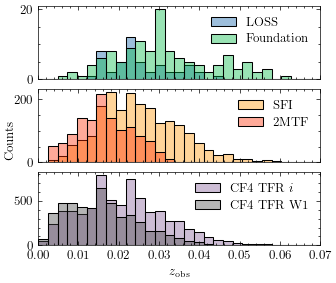

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

with plt.style.context('science'):
    plt.rcParams.update({'font.size': 9})
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10/3, 3), sharex=True)
    fig.subplots_adjust(hspace=0.0, wspace=0.0)
    cols = sns.color_palette()

    bins = np.linspace(0, 0.07, 30)
    alpha = 0.4
    edge_width = 0.75

    # First row: Foundation and LOSS
    sns.histplot(LOSS["z_CMB"], bins=bins, stat="count", alpha=alpha, label="LOSS", color=cols[0], edgecolor="black", ax=axes[0], linewidth=edge_width)
    sns.histplot(FOUNDATION["z_CMB"], bins=bins, stat="count", alpha=alpha, label="Foundation", color=cols[1], edgecolor="black", ax=axes[0], linewidth=edge_width)
    axes[0].set_ylabel(None)
    axes[0].legend()

    # Second row: 2MTF and SFI
    sns.histplot(SFI["z_CMB"], bins=bins, stat="count", alpha=alpha, label="SFI", color=cols[2], edgecolor="black", ax=axes[1], linewidth=edge_width)
    sns.histplot(TWOMTF["z_CMB"], bins=bins, stat="count", alpha=alpha, label="2MTF", color=cols[3], edgecolor="black", ax=axes[1], linewidth=edge_width)
    axes[1].set_ylabel(None)
    axes[1].legend()

    # Third row: CF4 samples
    m_i = CF4_TFR["i"] > 5
    sns.histplot(CF4_TFR["Vcmb"][m_i] / SPEED_OF_LIGHT, 
                 bins=bins, stat="count", alpha=alpha, label=catalogue_to_pretty("CF4_TFR_i"), color=cols[4], edgecolor="black", ax=axes[2], linewidth=edge_width)
    m_w1 = CF4_TFR["w1"] > 5
    sns.histplot(CF4_TFR["Vcmb"][m_w1] / SPEED_OF_LIGHT, 
                 bins=bins, stat="count", alpha=alpha, label=catalogue_to_pretty("CF4_TFR_w1"), color=cols[5], edgecolor="black", ax=axes[2], linewidth=edge_width)
    axes[2].set_xlabel(r"$z_{\rm obs}$")
    axes[2].set_ylabel(None)
    axes[2].legend()

    fig.text(0.03, 0.5, "Counts", va='center', ha='center', rotation='vertical')

    # Adjust layout
    plt.xlim(0, 0.07)
    plt.tight_layout(w_pad=0.2, h_pad=0.2)
    plt.savefig(f"../../plots/zcmb_dist.pdf", dpi=450)
    plt.show()


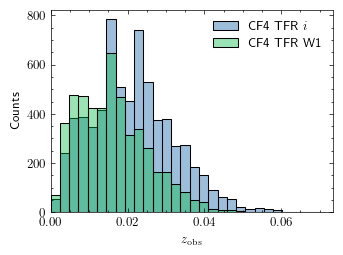

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

with plt.style.context('science'):
    plt.rcParams.update({'font.size': 9})

    fig, ax = plt.subplots()
    cols = sns.color_palette()

    bins = np.linspace(0, 0.07, 30)
    alpha = 0.4
    edge_width = 0.75

    m_i = CF4_TFR["i"] > 5
    sns.histplot(CF4_TFR["Vcmb"][m_i] / SPEED_OF_LIGHT, 
                 bins=bins, stat="count", alpha=alpha,
                 label=catalogue_to_pretty("CF4_TFR_i"), color=cols[0],
                 edgecolor="black", ax=ax, linewidth=edge_width)
    m_w1 = CF4_TFR["w1"] > 5
    sns.histplot(CF4_TFR["Vcmb"][m_w1] / SPEED_OF_LIGHT, 
                 bins=bins, stat="count", alpha=alpha,
                 label=catalogue_to_pretty("CF4_TFR_w1"), color=cols[1],
                 edgecolor="black", ax=ax, linewidth=edge_width)
    ax.set_xlabel(r"$z_{\rm obs}$")
    ax.set_ylabel(r"Counts")
    ax.set_xlim(0)
    ax.legend()

    fig.tight_layout()
    # fig.savefig(f"../../plots/zcmb_dist_cf4.pdf", dpi=450)
    # plt.savefig(f"../../plots/zcmb_dist.pdf", dpi=450)
    fig.show()


### 2. Sky distribution

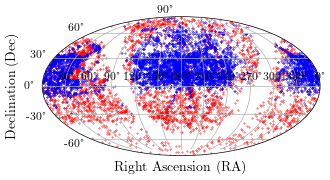

In [25]:
with plt.style.context("science"):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='mollweide')

    
    m = CF4_TFR["w1"] > 5
    ra = np.deg2rad(CF4_TFR["RA"][m]) - np.pi
    dec = np.deg2rad(CF4_TFR["DE"][m])
    ax.scatter(ra, dec, s=0.1, c='red', rasterized=True)

    m = CF4_TFR["i"] > 5
    ra = np.deg2rad(CF4_TFR["RA"][m]) - np.pi
    dec = np.deg2rad(CF4_TFR["DE"][m])
    ax.scatter(ra, dec, s=0.1, c='blue', rasterized=True)

    xticks = np.radians(np.arange(-150, 181, 30))  # Custom RA ticks in radians
    xtick_labels = np.radians(180 + np.arange(-150, 181, 30))  # Custom RA ticks in radians
    ax.set_xticks(xticks)
    ax.set_xticklabels([f'{round(np.degrees(tick)) % 360}°' for tick in xtick_labels], fontsize=8)

    yticks = np.radians(np.arange(-60, 91, 30))  # Custom Dec ticks in radians
    ax.set_yticks(yticks)
    ax.set_yticklabels([f'{round(np.degrees(tick))}°' for tick in yticks], fontsize=8)

    ax.set_xlabel('Right Ascension (RA)')
    ax.set_ylabel('Declination (Dec)')

    ax.grid(True)

    plt.tight_layout()
    # plt.savefig("../plots/HSC_galaxy_distribution.pdf", dpi=450)
    plt.show()

/tmp/ipykernel_3859591/4219257674.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


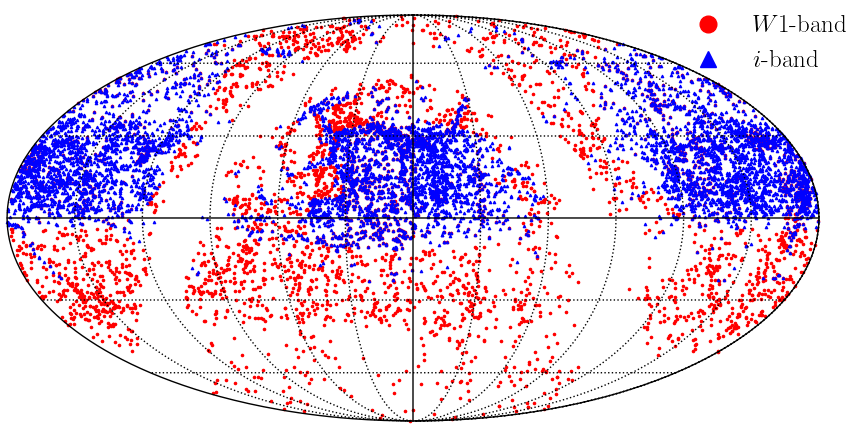

In [35]:
import matplotlib.lines as mlines

RA = CF4_TFR["RA"]
DEC = CF4_TFR["DEC"]

with plt.style.context("science"):
    hp.mollview(title=None, coord=['C'], notext=True)

    m = CF4_TFR["w1"] > 5
    theta = np.radians(90 - DEC[m])
    phi = np.radians(RA[m])
    hp.projscatter(theta, phi, lonlat=False, s=2.5, c='red', marker='o', label=r'$W1$-band')


    m = CF4_TFR["i"] > 5
    theta = np.radians(90 - DEC[m])
    phi = np.radians(RA[m])
    hp.projscatter(theta, phi, lonlat=False, s=2.5, c='blue', marker='^', label=r"$i$-band")

    # Add grid and legend
    hp.graticule()

    # Create custom legend with larger markers
    red_dot = mlines.Line2D([], [], color='red', marker='o', linestyle='None',
                            markersize=12, label=r'$W1$-band')
    blue_triangle = mlines.Line2D([], [], color='blue', marker='^', linestyle='None',
                                  markersize=12, label=r"$i$-band")

    plt.legend(handles=[red_dot, blue_triangle], loc='upper right', fontsize=18,
               bbox_to_anchor=(1.06, 1.05))

    plt.tight_layout()
    plt.savefig(f"../../plots/sky_dist_CF4.pdf", dpi=450)

    plt.show()

## Experimenting

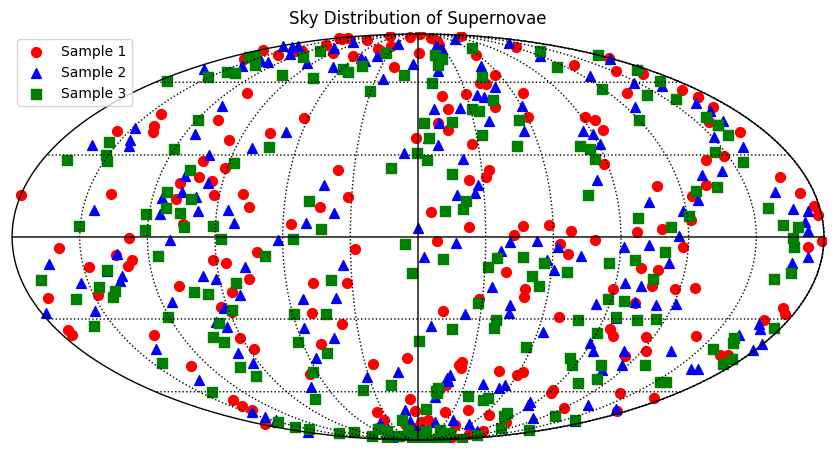

In [4]:
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np

# Create some random points for RA and DEC
num_points = 200
ra = np.random.uniform(0, 360, num_points)  # Right Ascension
dec = np.random.uniform(-90, 90, num_points)  # Declination

# Convert RA, DEC to theta and phi for healpy (in radians)
theta = np.radians(90 - dec)  # Theta is 90 - dec in radians
phi = np.radians(ra)  # Phi is ra in radians

# Set up a Mollweide projection
hp.mollview(title='Sky Distribution of Supernovae', coord=['C'], notext=True)

# Scatter plot the points
hp.projscatter(theta, phi, lonlat=False, s=50, c='red', marker='o', label='Sample 1')
hp.projscatter(theta + 0.1, phi + 0.1, lonlat=False, s=50, c='blue', marker='^', label='Sample 2')
hp.projscatter(theta + 0.2, phi + 0.2, lonlat=False, s=50, c='green', marker='s', label='Sample 3')

# Add grid and legend
hp.graticule()
plt.legend()
plt.show()